# **APS1: EDA**

Membros do projeto: Luiz Miguel e Lucas Kenji

Entrega: 12 Marco, 2026

Realizando importações necessarias para o projeto

In [26]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import accuracy_score
from scipy.stats.mstats import winsorize

## 1. **Carregamento e inspeção inicial dos dados**

### **Explicando cada feature e identificando os tipos de dados do dataset**

- `age`:    **Idade do indivíduo** (contínua);
- `workclass`:  **Categoria do trabalho** (categórica);
- `fnlwgt`:     **Peso final** (contínua);
- `education`:  **Nível de escolaridade** (categórica);
- `education-num`:  **Nível de escolaridade em grau** (contínua);
- `marital-status`:     **Estado civil** (categórica);
- `occupation`:     **Ocupação profissional** (categórica);
- `relationship`:   **Relacionamento** (categórica);
- `race`:   **Etnia** (categórica);
- `sex`:    **Gênero** (categórica);
- `capital-gain`:   **Ganhos de capital** (contínua);
- `capital-loss`:   **Perdas de capital** (contínua);
- `hours-per-week`:     **Horas de trabalho semanais** (contínua);
- `native-country`:     **País de origem** (categórica);
- `income`:     **Renda anual** (contínua);

### **Carregamento e analise dos datasets:**
- Conjunto de treino: `adult.data`

In [27]:
# Carregando o dataset adult.data
df_train = pd.read_csv('dataset/adult.data', header=None)
df_train.columns = ['age', 'workclass', 'fnlwgt', 'education', 'education-num',
              'marital-status', 'occupation', 'relationship', 'race', 'sex',
              'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
              'income']
df_train.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


- Conjunto de teste: `adult.test`

In [28]:
# Carregando o dataset adult.test
df_test = pd.read_csv('dataset/adult.test', header=None, skiprows=1)
df_test.columns = ['age', 'workclass', 'fnlwgt', 'education', 'education-num',
              'marital-status', 'occupation', 'relationship', 'race', 'sex',
              'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
              'income']
# df_test.head()

### **Verificando o número de instâncias e features**

In [29]:
df_train.shape, df_test.shape

((32561, 15), (16281, 15))

In [30]:
df_train.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'income'],
      dtype='str')

Dentro do dataset de treino possuimos **32561** instâncias e **14** features (e 1 target)

### **Analisando a distruibuicao da target**

<Axes: xlabel='income', ylabel='Count'>

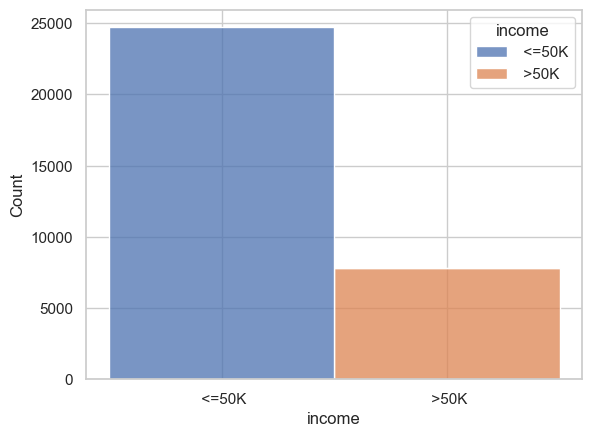

In [31]:
# Histograma da variável alvo 'income' para análise de distribuição
sns.histplot(data=df_train, x='income', hue='income', multiple='stack')

## 2. **Análise univariada**

### **Medidas descritivas para variáveis contínuas.**

In [32]:
# Features numéricas
numericals = ['age', 'fnlwgt', 'capital-gain', 'education-num', 'capital-loss', 'hours-per-week']

# Estatísticas descritivas para variáveis numéricas
df_train[numericals].describe()

,age,fnlwgt,capital-gain,education-num,capital-loss,hours-per-week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,1077.648844,10.080679,87.303830,40.437456
std,13.640433,1.055500e+05,7385.292085,2.572720,402.960219,12.347429
min,17.000000,1.228500e+04,0.000000,1.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,0.000000,9.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,0.000000,10.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,0.000000,12.000000,0.000000,45.000000
max,90.000000,1.484705e+06,99999.000000,16.000000,4356.000000,99.000000


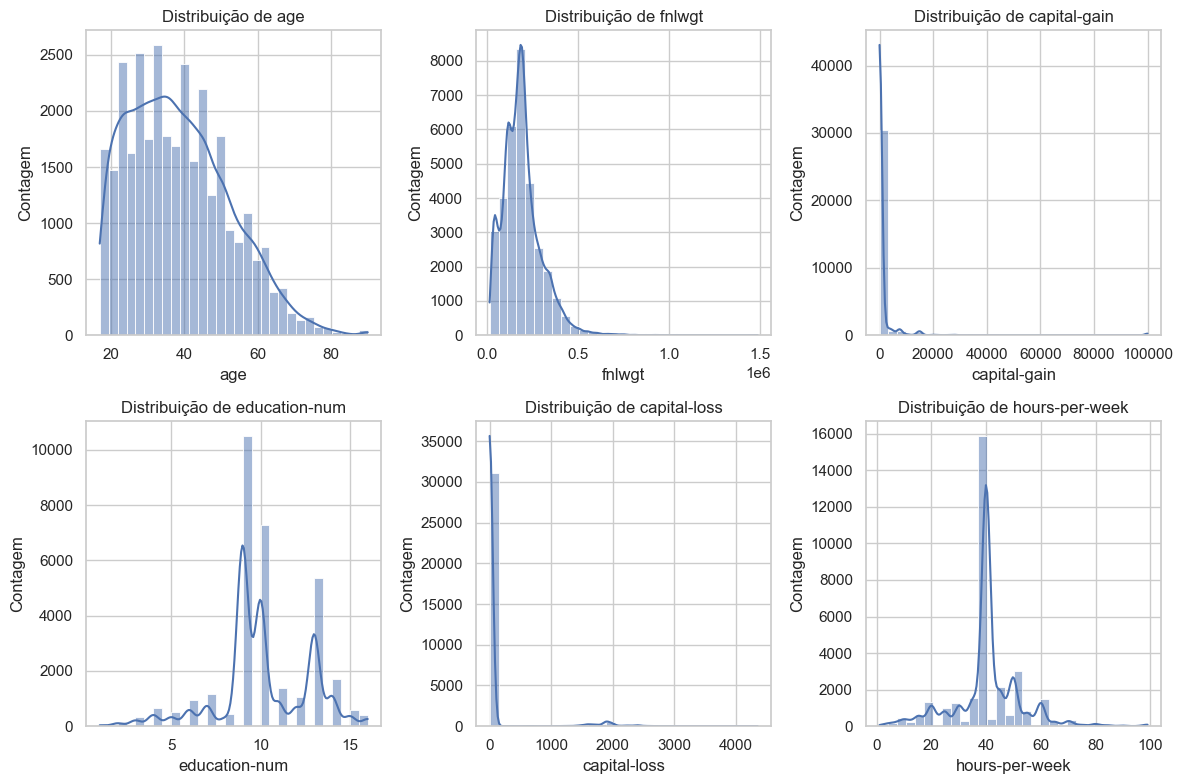

In [33]:
# Histogramas para variáveis numéricas para análise de distribuição
plt.figure(figsize=(12, 8))
for i, col in enumerate(numericals):
    plt.subplot(2, 3, i + 1)
    sns.histplot(df_train[col], kde=True, bins=30)  # bins=30 para melhor granularidade; kde para curva de densidade
    plt.title(f'Distribuição de {col}')
    plt.xlabel(col)
    plt.ylabel('Contagem')
plt.tight_layout()
plt.show()

### **Medidas descritivas para variáveis categóricas.**

       workclass education       marital-status       occupation relationship  \
count      32561     32561                32561            32561        32561   
unique         9        16                    7               15            6   
top      Private   HS-grad   Married-civ-spouse   Prof-specialty      Husband   
freq       22696     10501                14976             4140        13193   

          race    sex  native-country  
count    32561  32561           32561  
unique       5      2              42  
top      White   Male   United-States  
freq     27816  21790           29170  

                                                         Frequency
workclass  education     marital-status      occupation         relationship   race                sex     native-country
Private    HS-grad       Married-civ-spouse  Craft-repair       Husband        White               Male    United-States     803
           Bachelors     Married-civ-spouse  Exec-managerial    Husband    

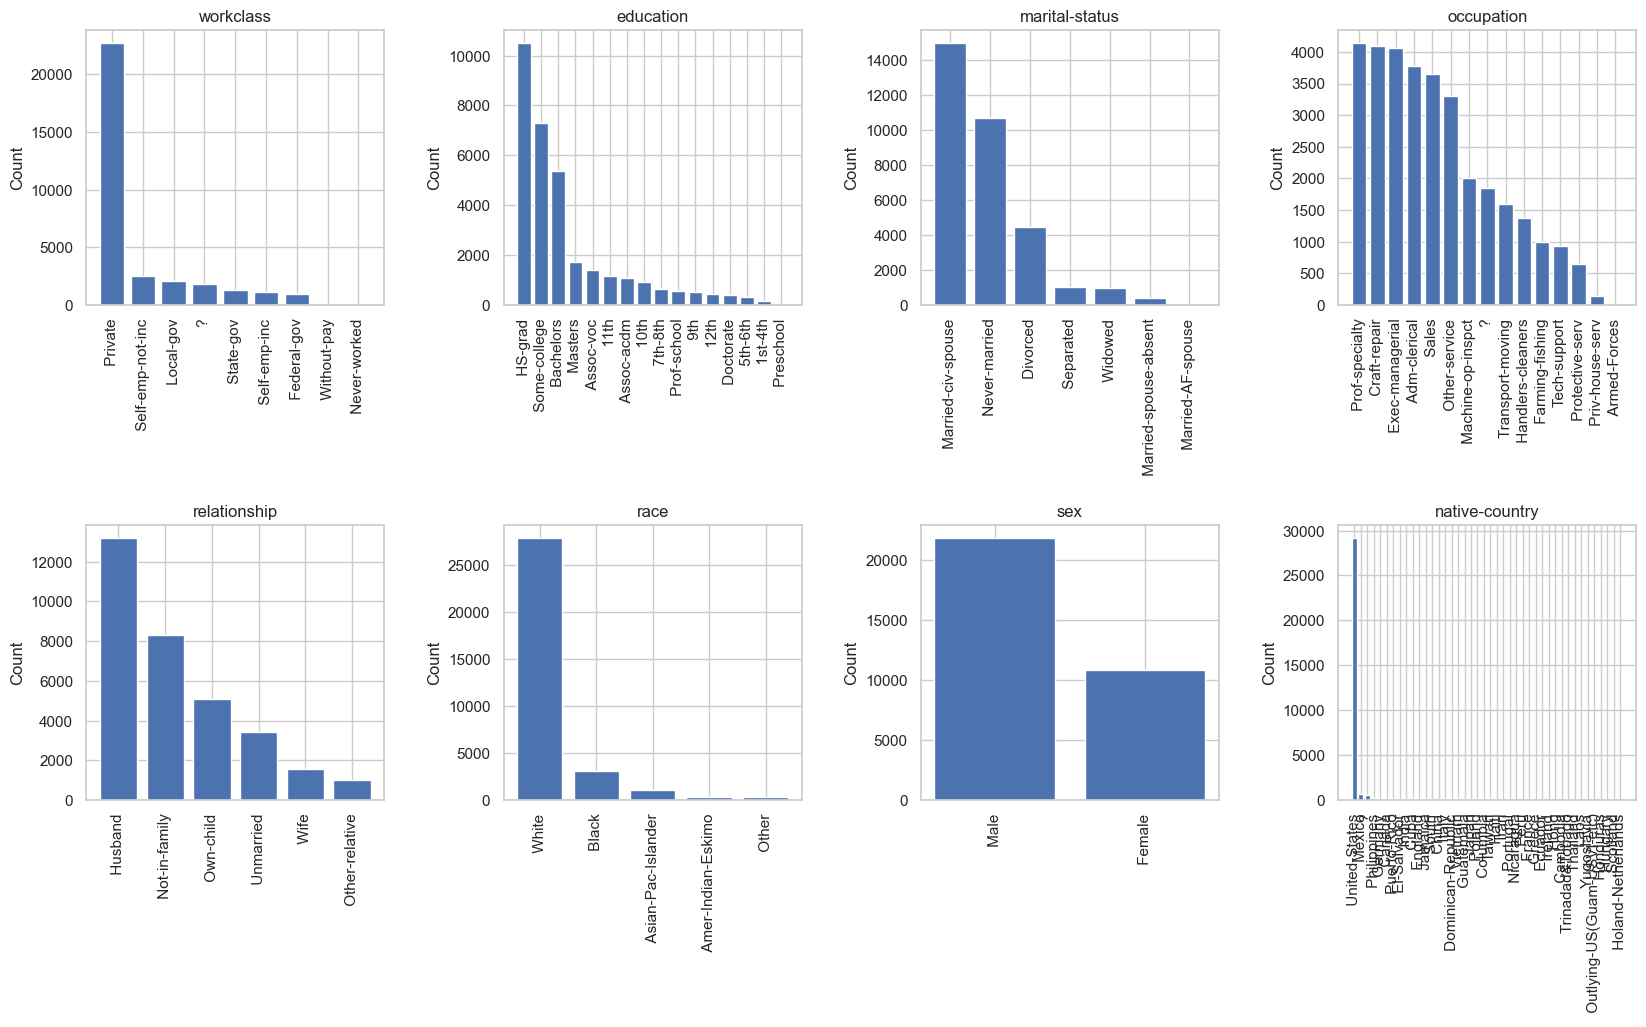

In [34]:
# Features categóricas
categories = ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']

print("===================================================================================================================================")
print(df_train[categories].describe()) # Estatísticas descritivas para variáveis categóricas
print("\n===================================================================================================================================")
print("                                                         Frequency")
print("===================================================================================================================================")
print(df_train[categories].value_counts()) # Frequências para variáveis categóricas

# Visualização das distribuições das variáveis categóricas
i = 1
plt.figure(figsize=(20, 10))
for col in categories:
    plt.subplot(2, 4, i)
    plt.bar(df_train[col].value_counts().index.astype(str), df_train[col].value_counts().values) # Gráfico de barras para categorias
    plt.ylabel("Count")
    plt.title(col)
    plt.xticks(rotation=90)
    i += 1
plt.subplots_adjust(hspace=0.8, wspace=0.4)
plt.show()

### **Detecção de outliers nas variaveis númericas**

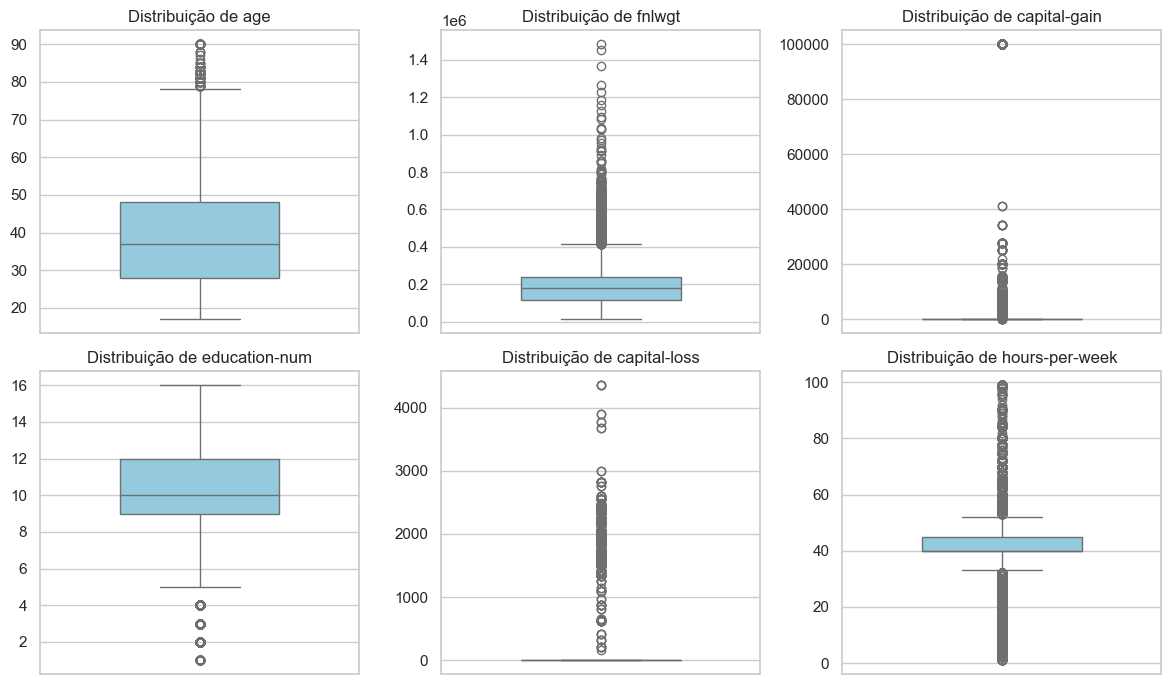

In [35]:
# Definindo o estilo visual
sns.set_theme(style="whitegrid") 

# Criando a figura com o tamanho desejado
plt.figure(figsize=(12, 7))

# Loop para criar um subplot para cada variável numérica
for i, col in enumerate(numericals):
    plt.subplot(2, 3, i + 1) # Ajuste (2, 3) conforme o número de colunas
    sns.boxplot(y=df_train[col], color='skyblue', width=0.5)
    plt.title(f'Distribuição de {col}', fontsize=12)
    plt.ylabel('') # Remove o label repetitivo do eixo Y

# Ajusta o espaçamento entre os gráficos automaticamente
plt.tight_layout()
plt.show()

## 3. **Análise bivariada e multivariada**

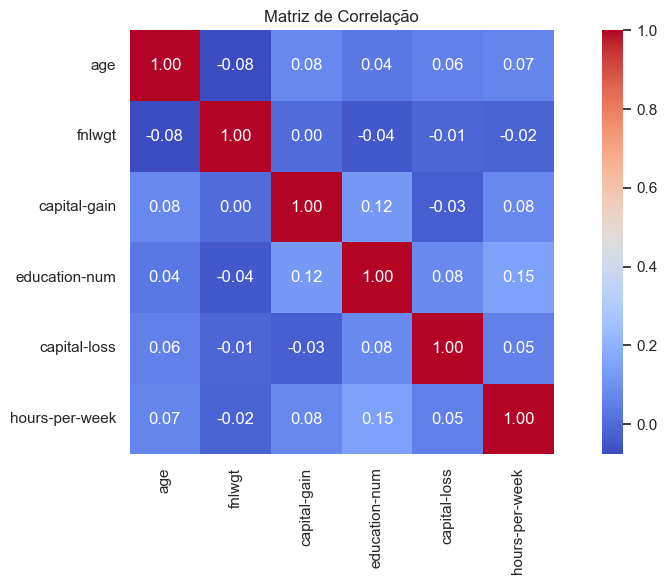

In [36]:
# Criando a matriz de correlação para as variáveis numéricas
corr_matrix = df_train[numericals].corr()

# Plotando o  heatmap
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(corr_matrix, fmt='.2f', square=True, linecolor='white', annot=True, cmap="coolwarm");
plt.title('Matriz de Correlação')
plt.tight_layout()

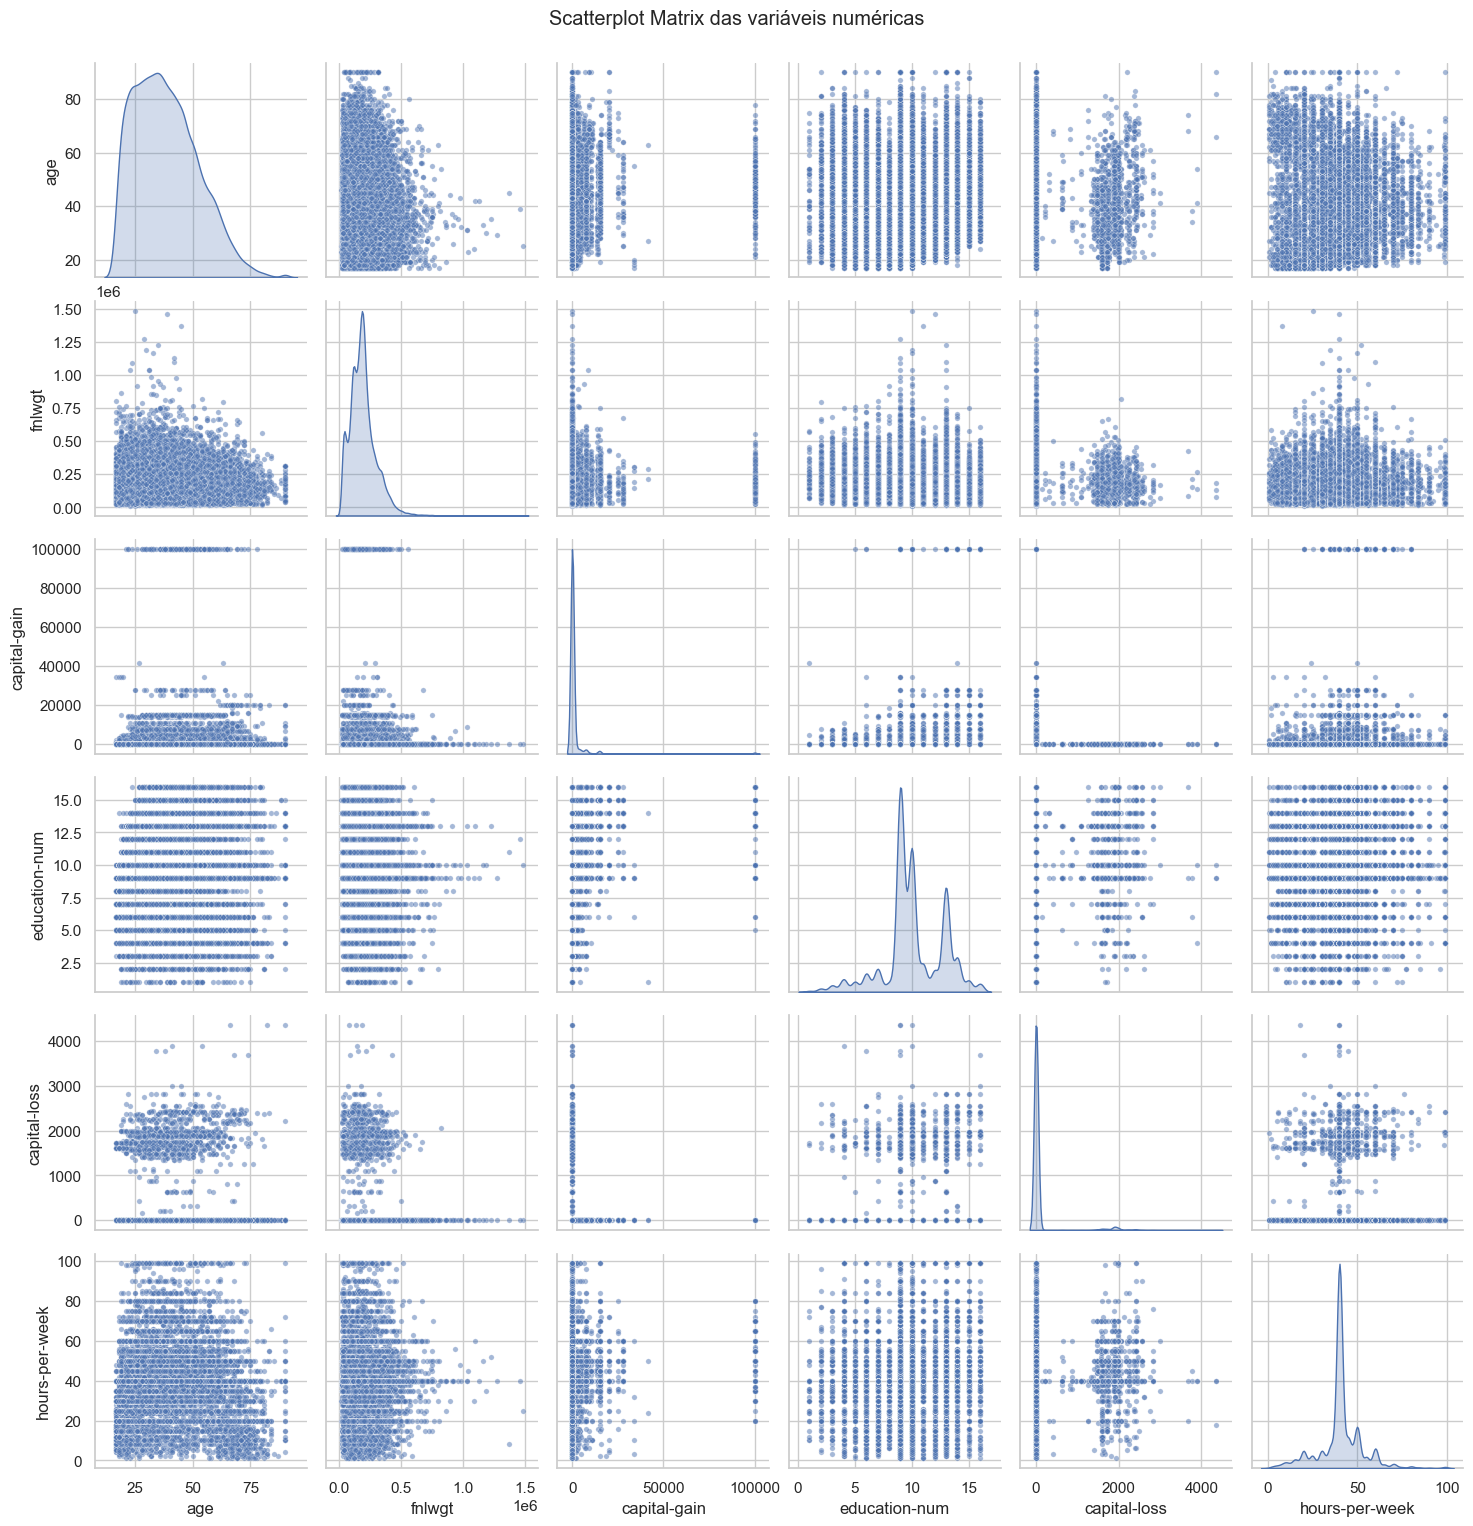

In [50]:
# Scatterplot matrix (Pairplot) das variáveis numéricas para analisar relações pairwise
sns.pairplot(df_train[numericals], kind="scatter", diag_kind="kde", plot_kws={"alpha": 0.5, "s": 15})
plt.suptitle('Scatterplot Matrix das variáveis numéricas', y=1.02)
plt.show()


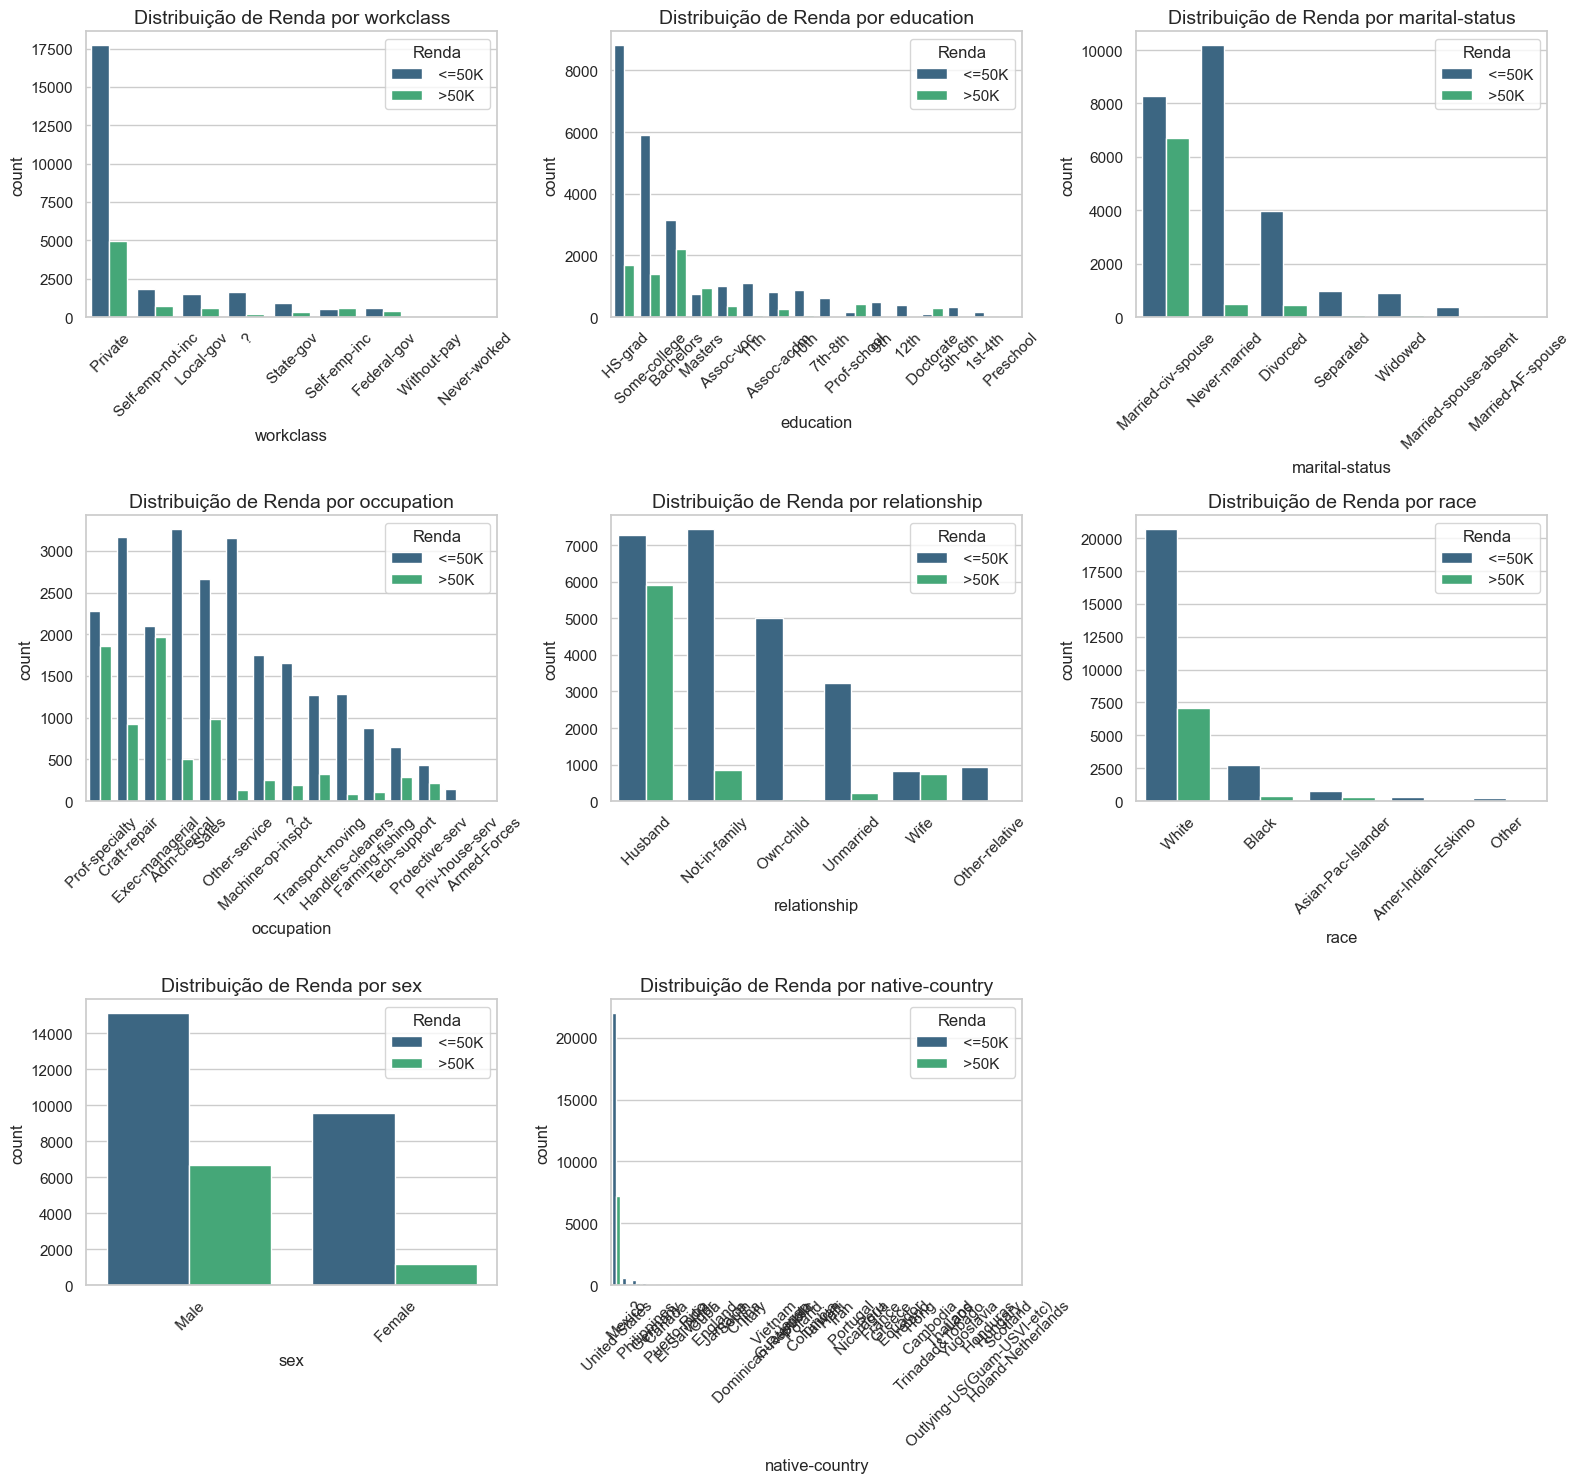

In [37]:
cols = 3 # Número de colunas para os subplots
rows = (len(categories) + cols - 1) // cols 

# Criando os subplots para as variáveis categóricas
fig, axes = plt.subplots(rows, cols, figsize=(16, 5 * rows))
axes = axes.flatten()

# Loop para criar um subplot para cada variável categórica, mostrando a distribuição de 'income' para cada categoria
for i, col in enumerate(categories):
    order = df_train[col].value_counts().index
    sns.countplot(data=df_train, x=col, hue='income', ax=axes[i], palette='viridis', order=order)
    
    axes[i].set_title(f'Distribuição de Renda por {col}', fontsize=14)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend(title='Renda', loc='upper right')
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()


--- Analisando Distribuição de Variáveis Numéricas por WORKCLASS ---


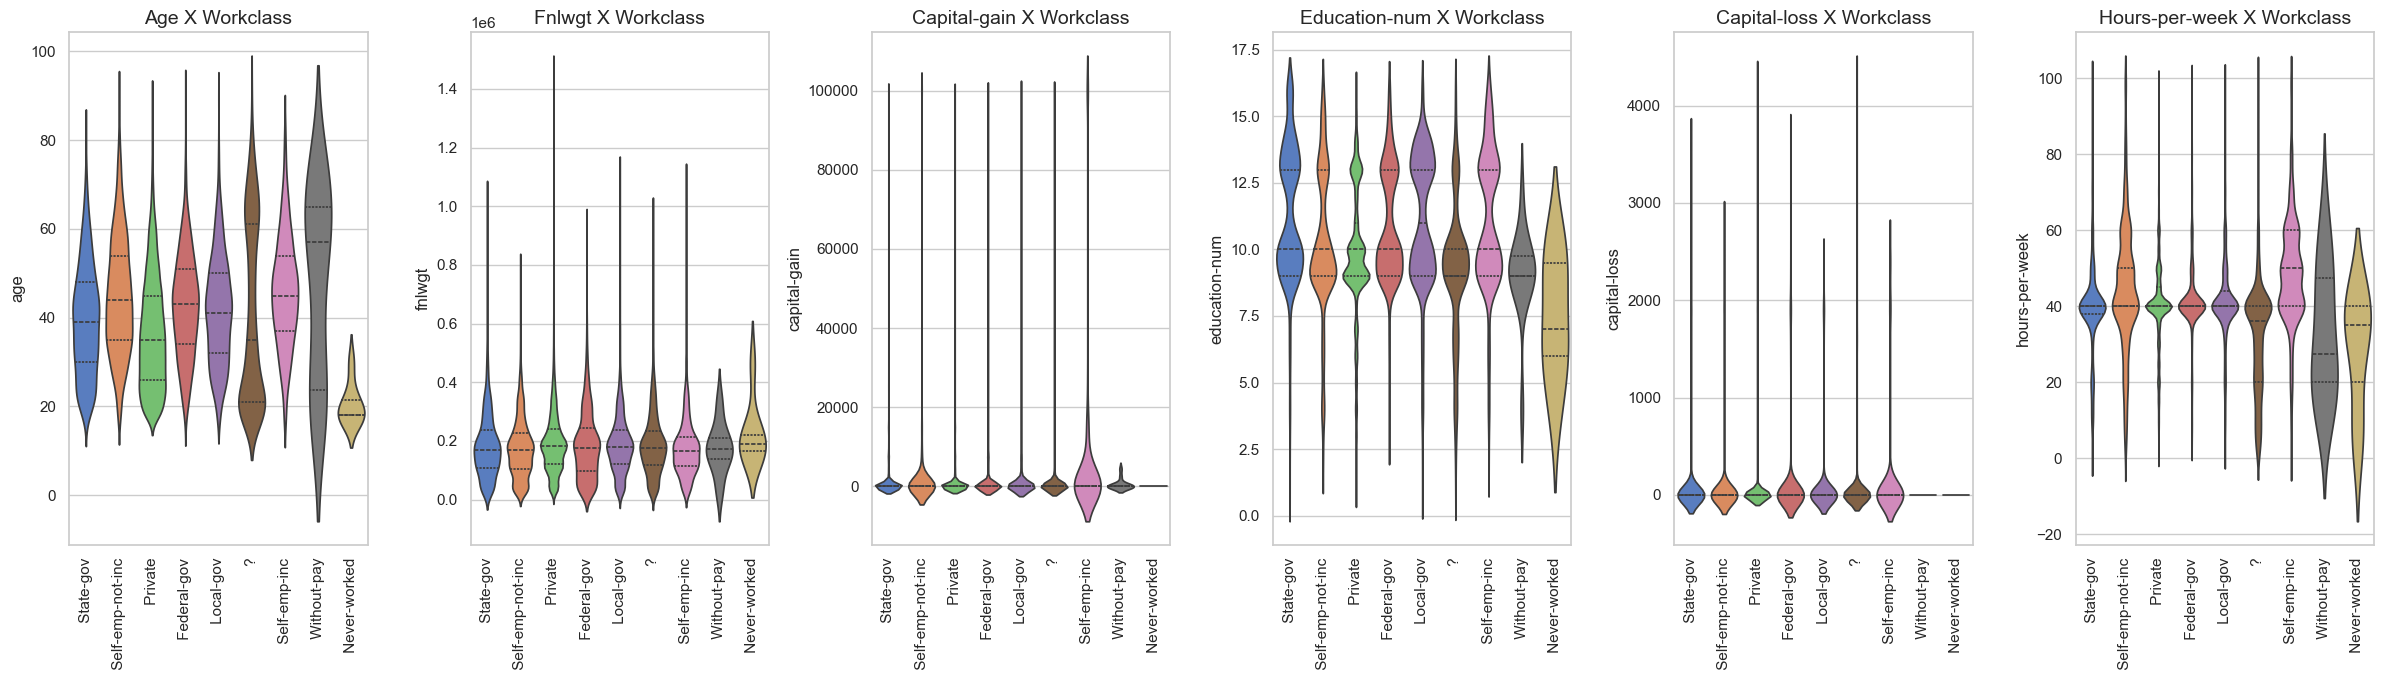


--- Analisando Distribuição de Variáveis Numéricas por EDUCATION ---


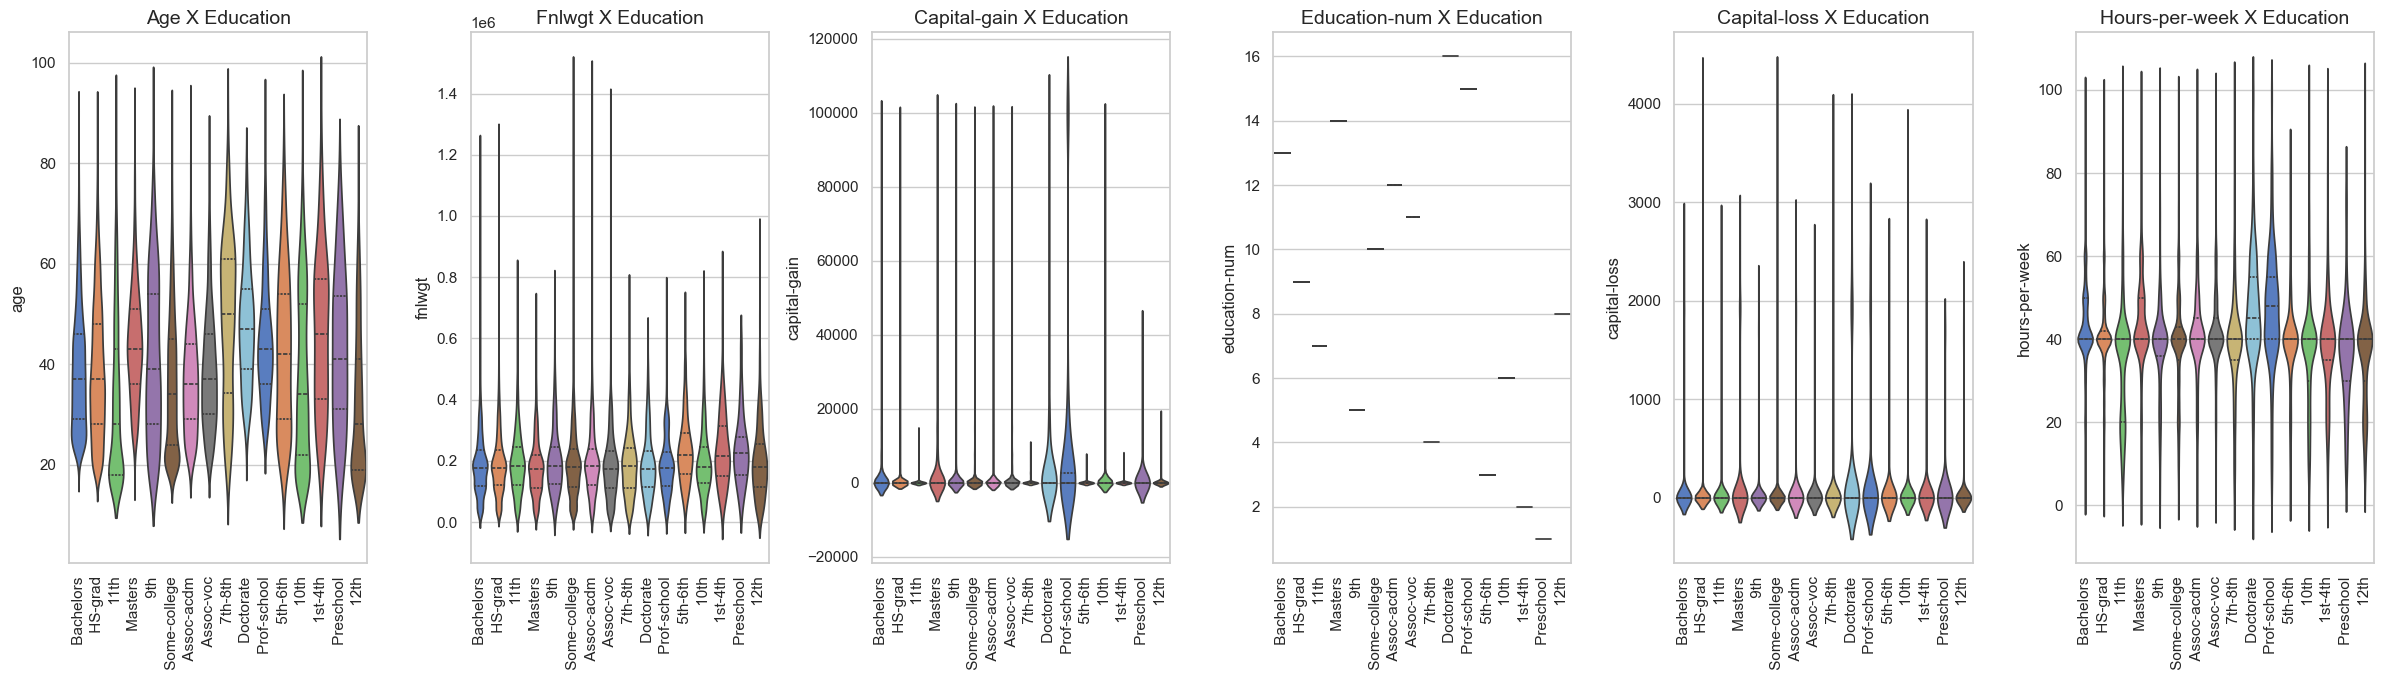


--- Analisando Distribuição de Variáveis Numéricas por MARITAL-STATUS ---


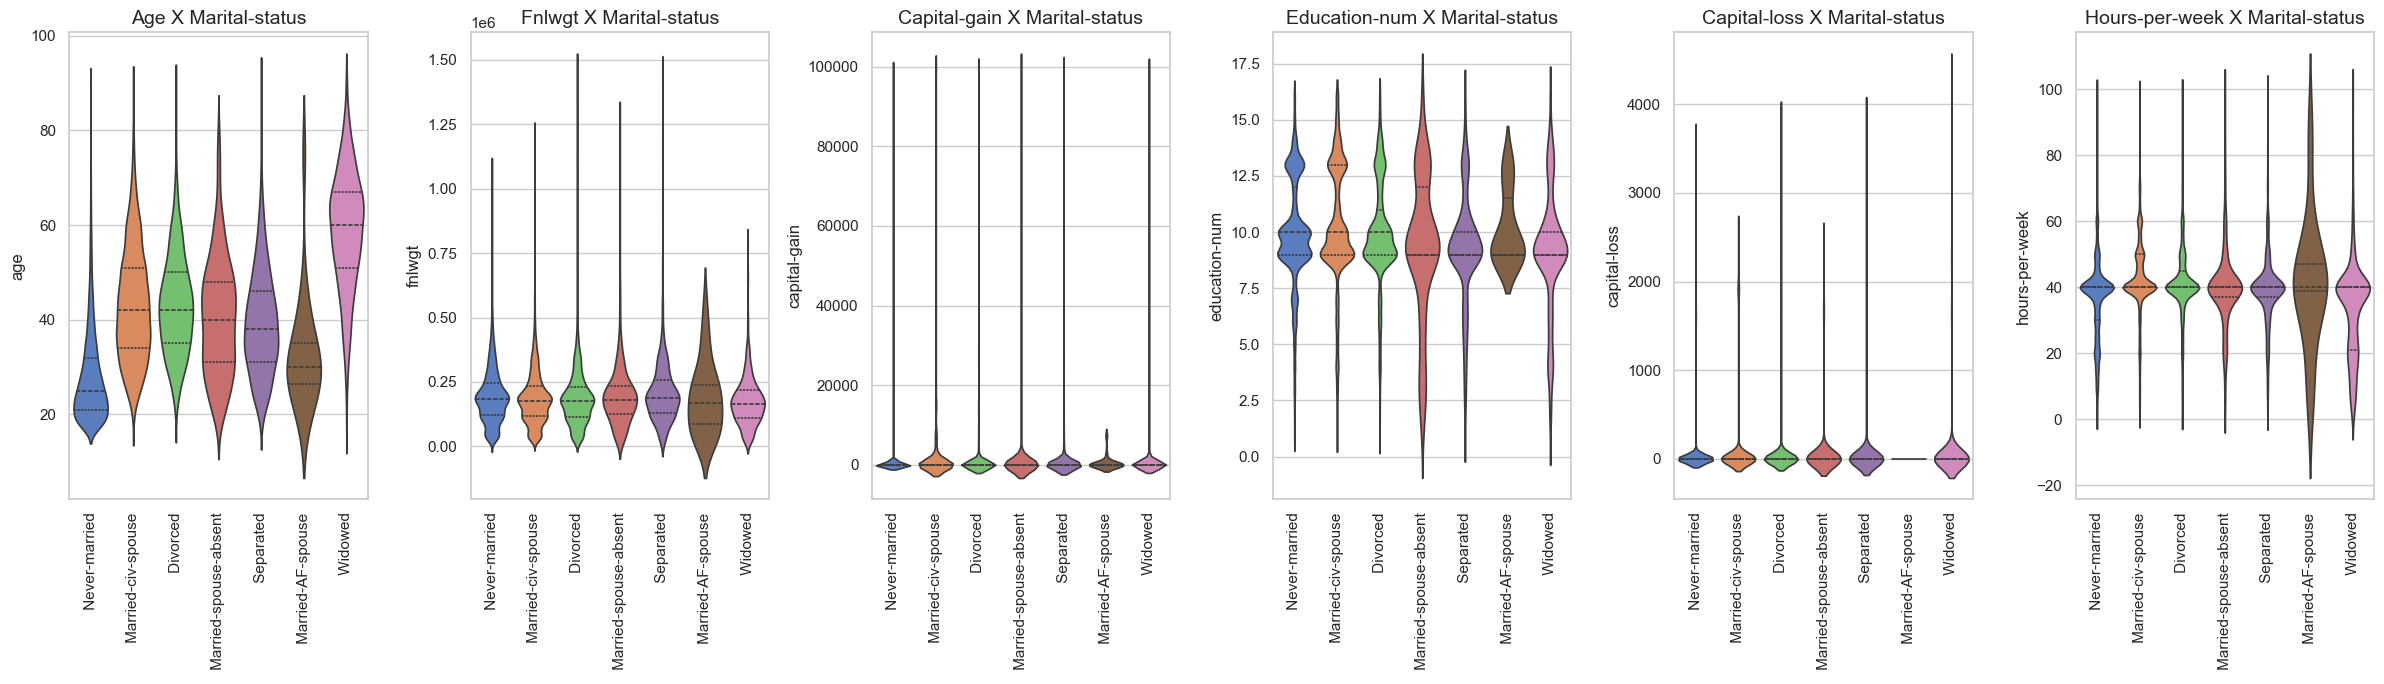


--- Analisando Distribuição de Variáveis Numéricas por OCCUPATION ---


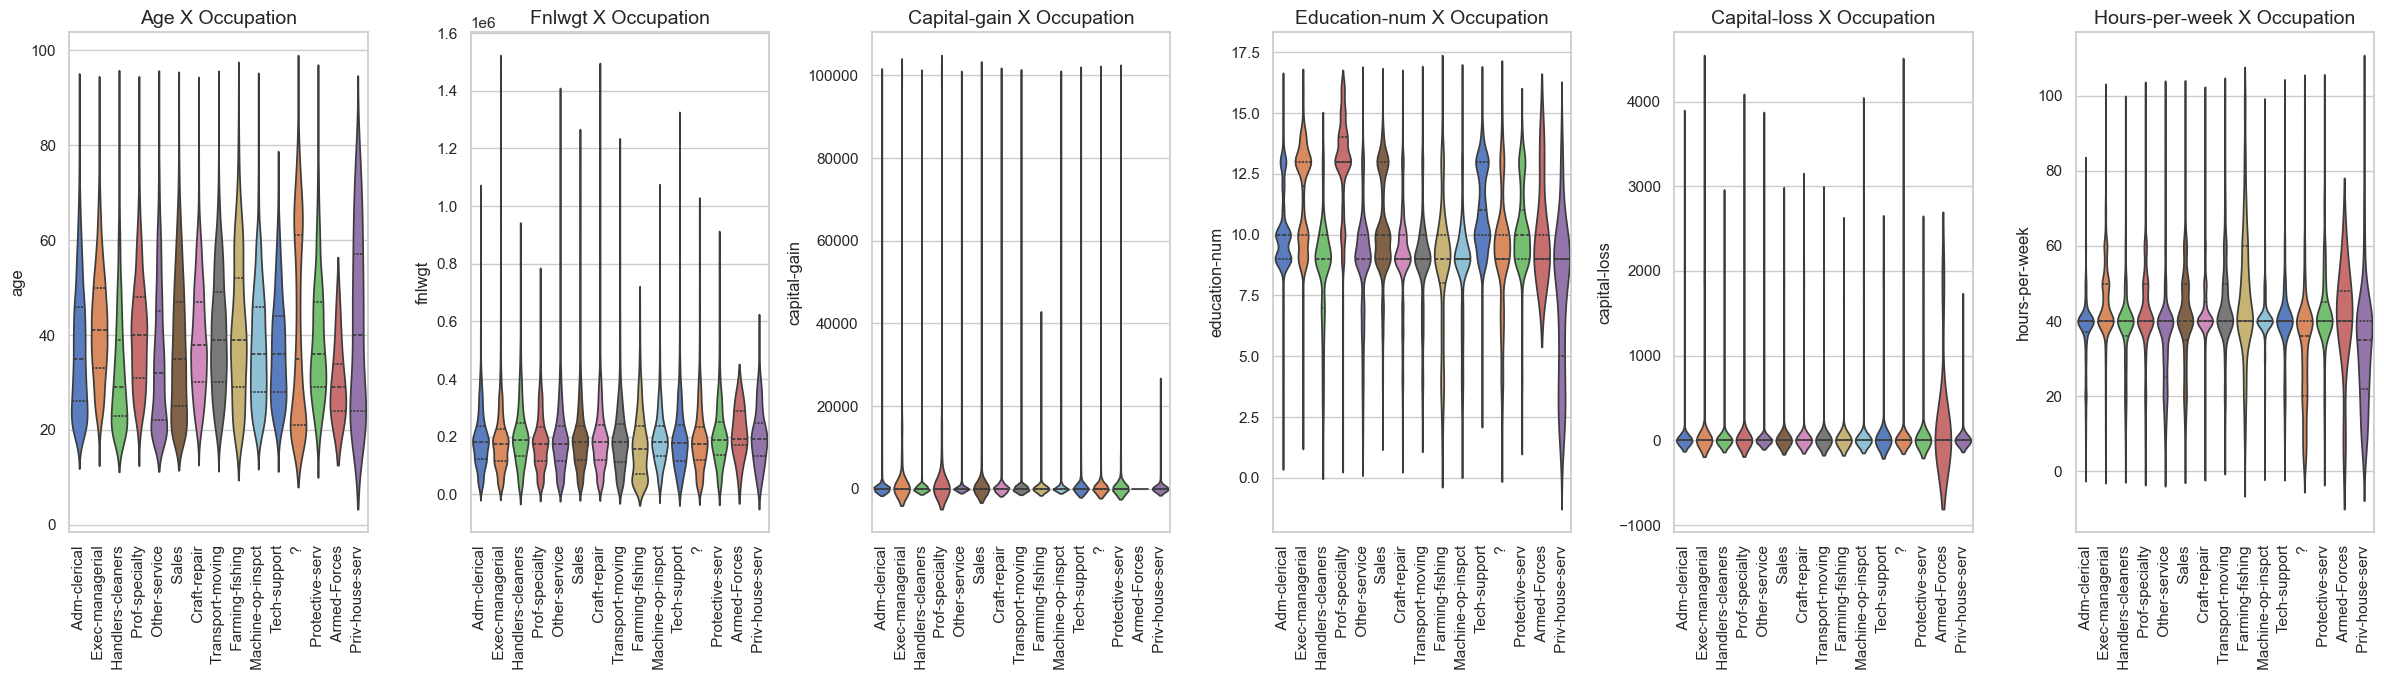


--- Analisando Distribuição de Variáveis Numéricas por RELATIONSHIP ---


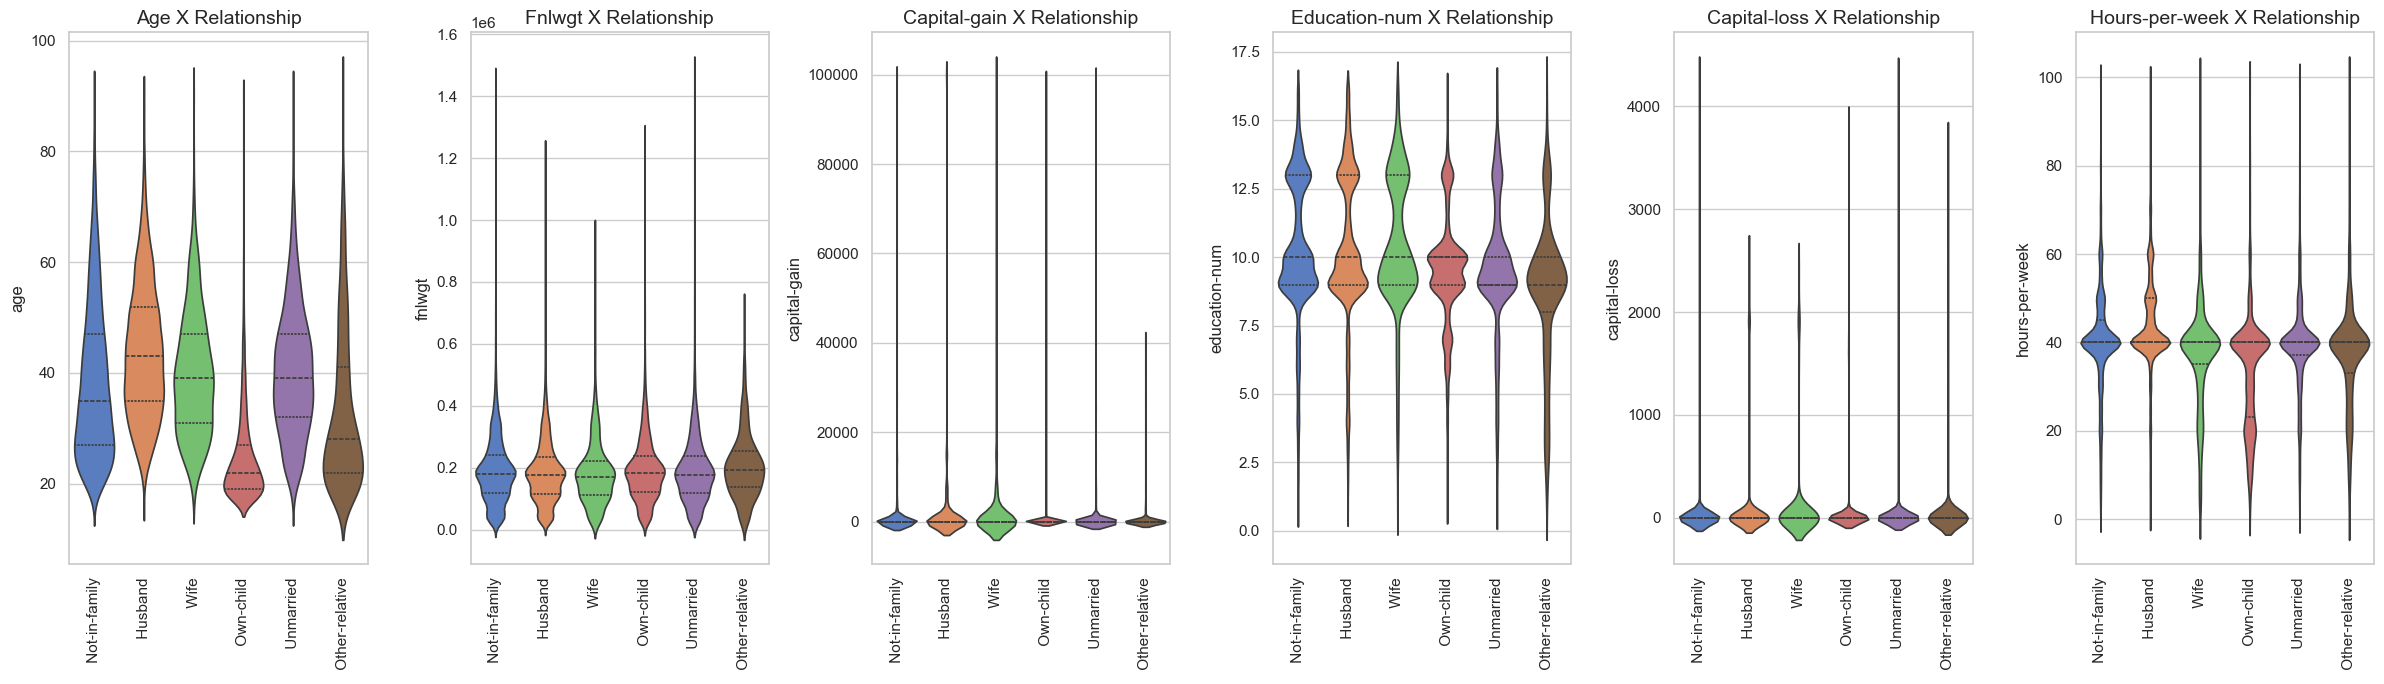


--- Analisando Distribuição de Variáveis Numéricas por RACE ---


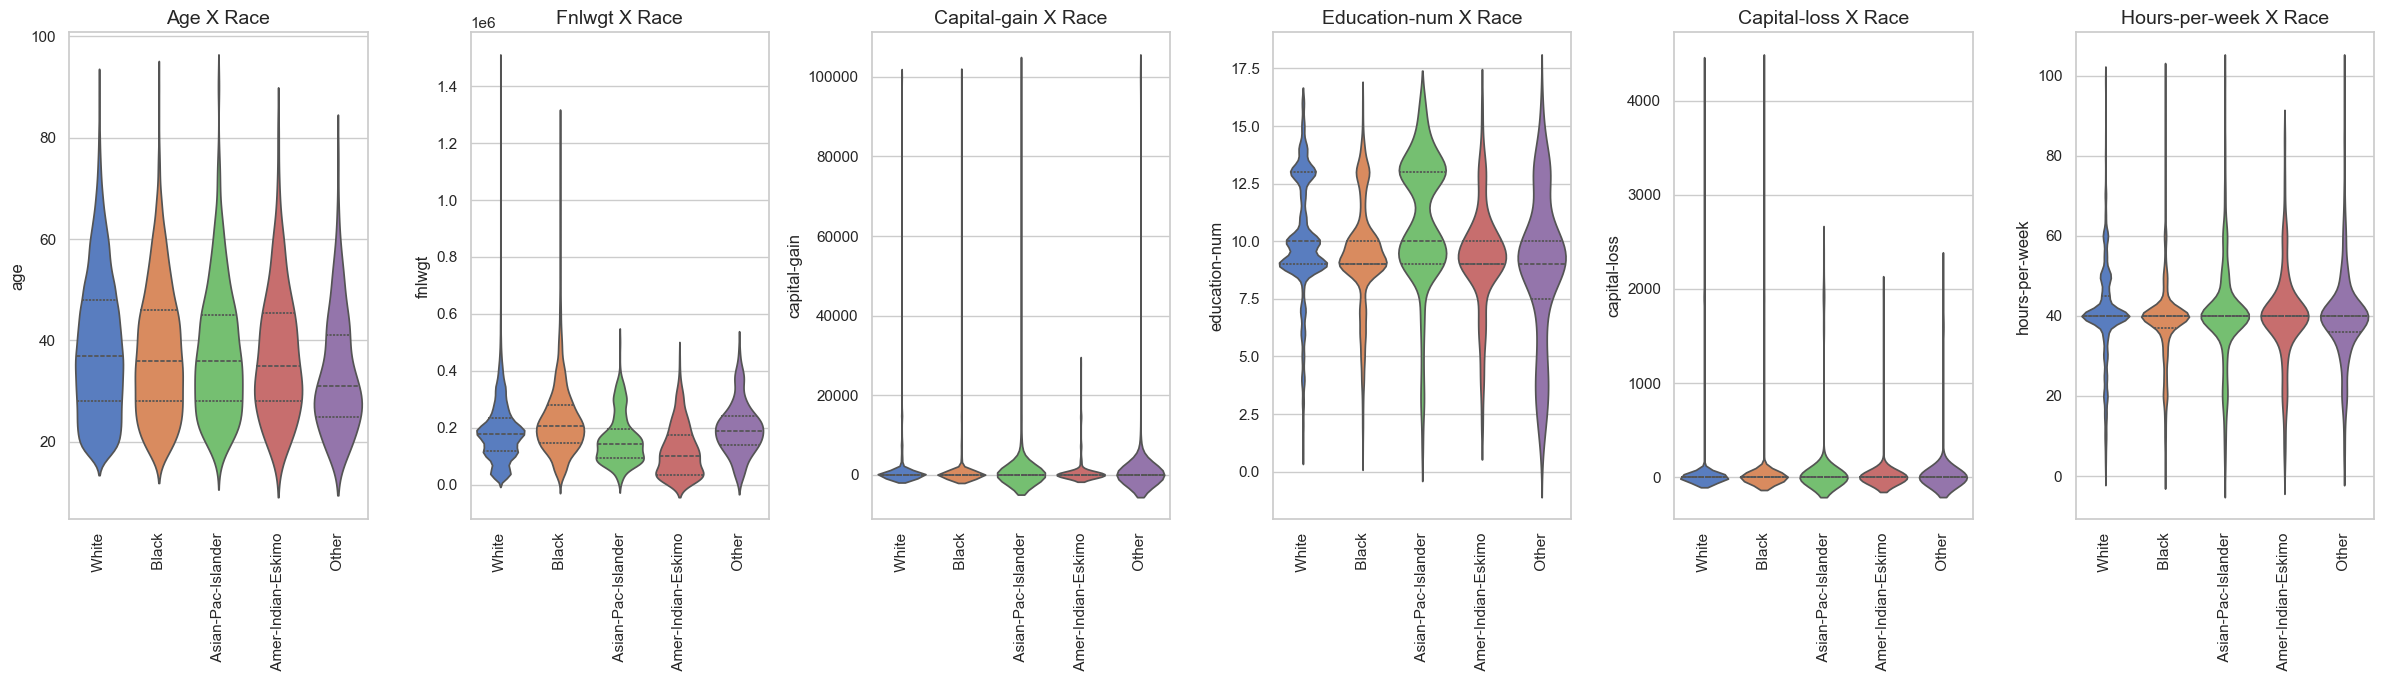


--- Analisando Distribuição de Variáveis Numéricas por SEX ---


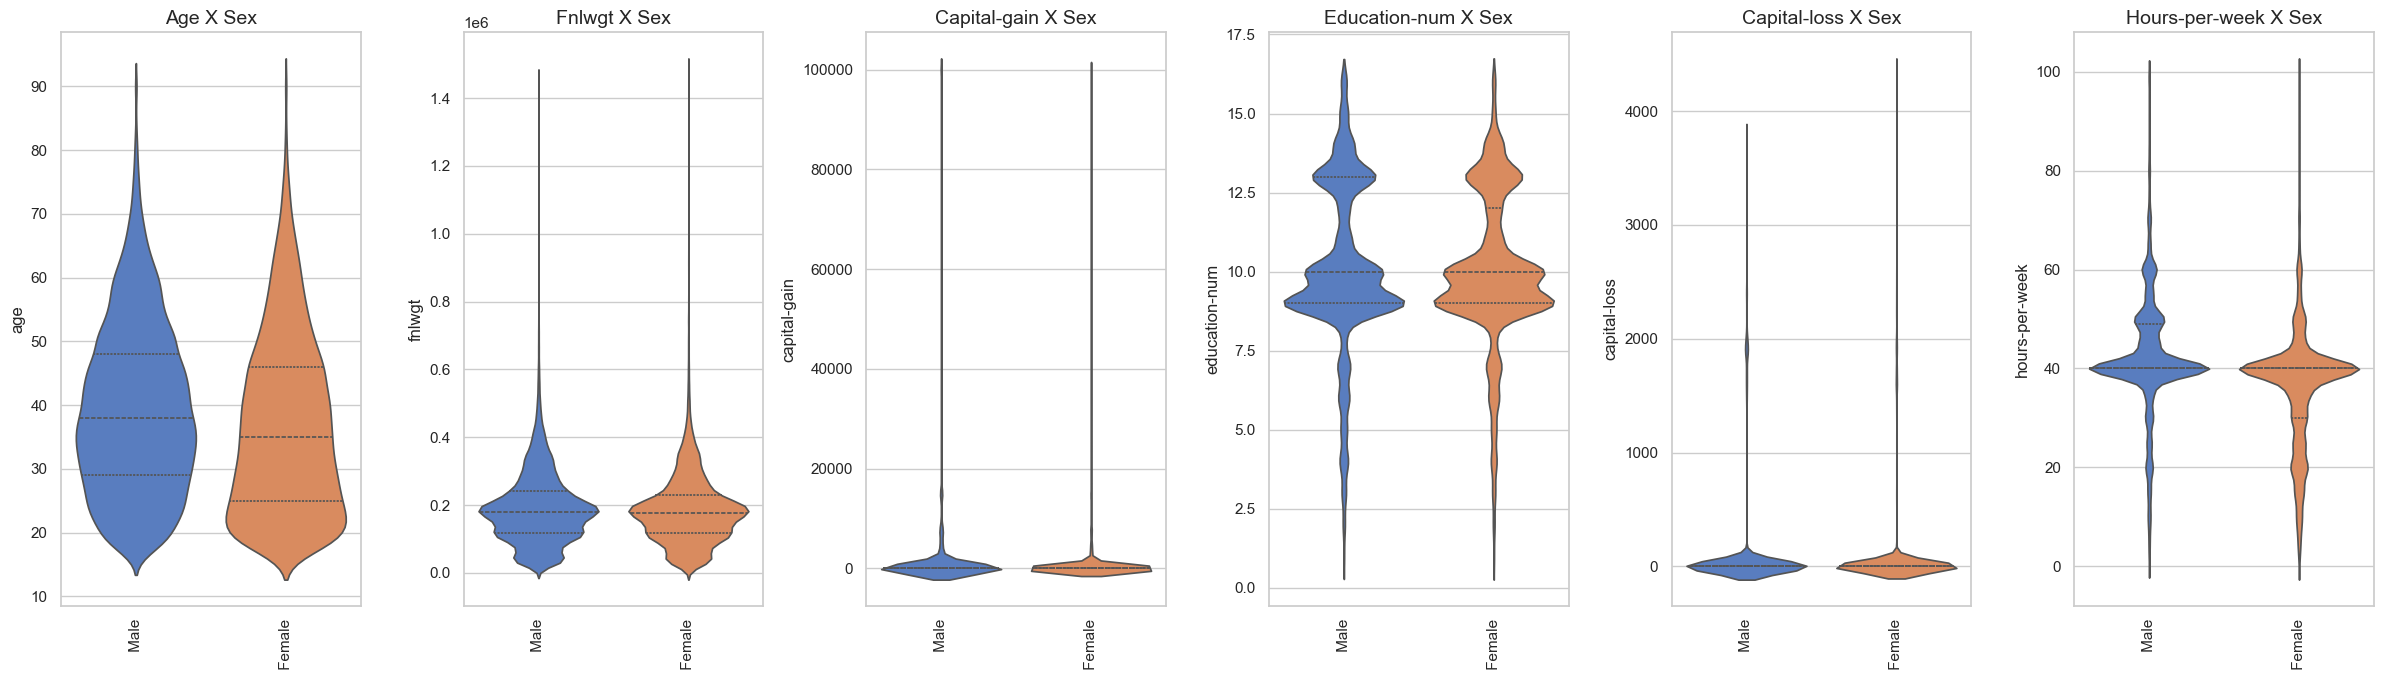


--- Analisando Distribuição de Variáveis Numéricas por NATIVE-COUNTRY ---


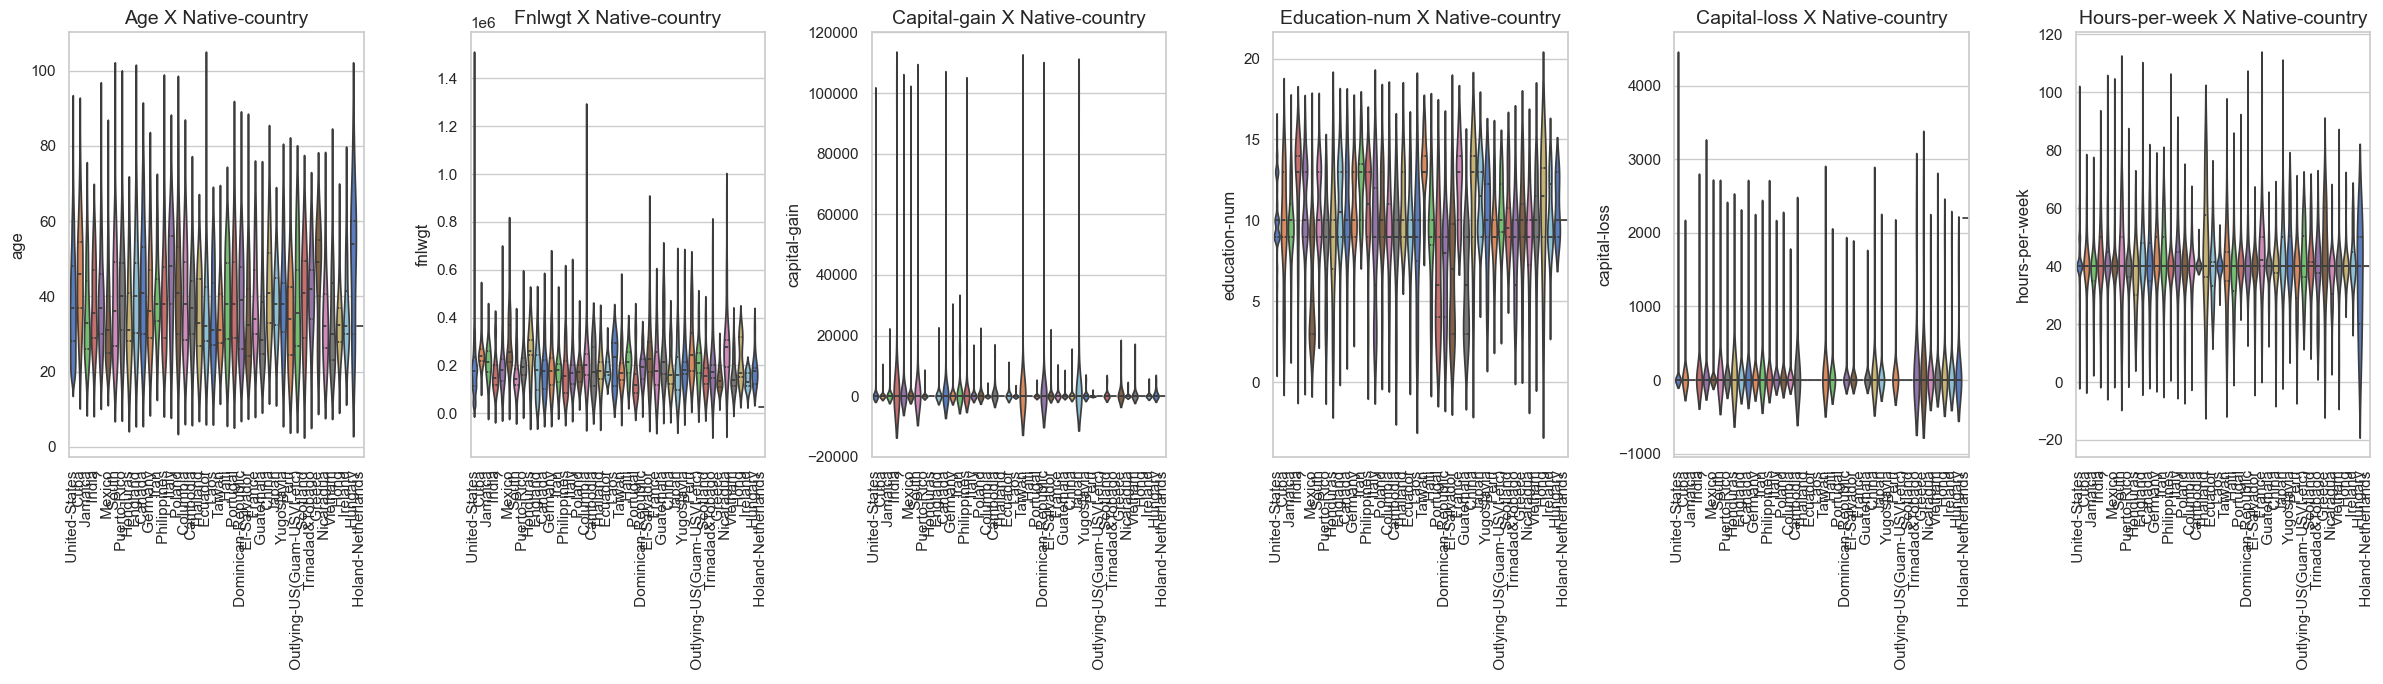

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

# Silencia avisos genéricos para manter o notebook limpo
warnings.filterwarnings('ignore', category=FutureWarning)

sns.set_theme(style="whitegrid")

# Loop para criar gráficos de violino para cada variável numérica em relação a cada variável categórica
for cat in categories:
    print(f"\n--- Analisando Distribuição de Variáveis Numéricas por {cat.upper()} ---")
    
    fig, axes = plt.subplots(1, len(numericals), figsize=(24, 7))
    
    if len(numericals) == 1:
        axes = [axes]

    for j, num in enumerate(numericals):
        sns.violinplot(
            data=df_train, 
            x=cat, 
            y=num, 
            ax=axes[j], 
            hue=cat,          # Atribui hue ao x para evitar o FutureWarning
            palette='muted', 
            inner="quartile", 
            legend=False      # Remove a legenda repetitiva, já que o eixo X já identifica a cor
        )
        
        axes[j].set_title(f'{num.capitalize()} X {cat.capitalize()}', fontsize=14)
        axes[j].tick_params(axis='x', rotation=90)
        axes[j].set_xlabel('') 
        
    plt.tight_layout()
    plt.show()

## 4. **Análise de qualidade dos dados**

### **Detecção de valores ausentes ('?') e inconsistênias.**

In [39]:
# remover espaços em branco antes do '?'
df_train.replace(' ?', '?', inplace=True)
missing_counts = df_train.isin(['?']).sum()

# Colunas com valores ausentes.
missing_columns = missing_counts[missing_counts > 0].index.tolist()

print("=====================================")
print("Contagem de '?' por coluna no treino:")
print("=====================================")
print(missing_counts)

missing_columns

Contagem de '?' por coluna no treino:
age                  0
workclass         1836
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     583
income               0
dtype: int64


['workclass', 'occupation', 'native-country']

Dentro do nosso dataset de treino as features: `workclass`, `occupation` e `native_country` possuem dados faltantes.

Alem disso, as colunas `education` e `education-num` são redundantes, pois representam os mesmos dados. Na etapa de pre-processamento sera removida para evitar incosistencias.

### **Analisando distribuicao de classes da target para detectar desequilibrios**

In [40]:
df_train['income'].describe()

count      32561
unique         2
top        <=50K
freq       24720
Name: income, dtype: object

In [ ]:
counts = df_train['income'].value_counts() # Contagem de cada categoria na variável 'income'
percentage = df_train['income'].value_counts(normalize=True) * 100 # Porcentagem de cada categoria na variável 'income'

# Criacao do DataFrame para exibir contagem e porcentagem
dist = pd.DataFrame({
    'Count': counts,
    'Percentage': percentage
})

dist

,Count,Percentage
income,,
<=50K,24720,75.919044
>50K,7841,24.080956


<Axes: >

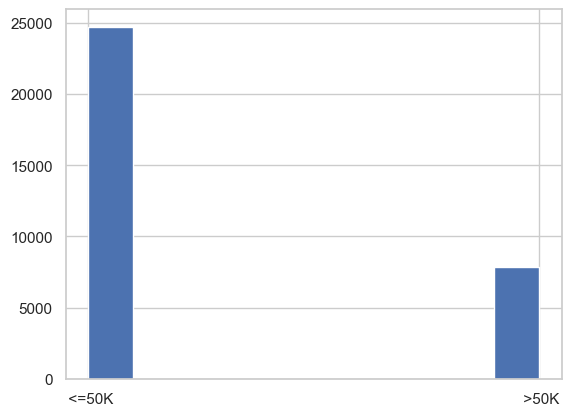

In [51]:
df_train['income'].hist()

Fazendo a analise de distribuicao de classes da nossa target `income`, percebe-se um desequilibrio, com mais de 70% dos dados do dataset de uma unica classe.

Porcentagem >50K por Race:
 race
Amer-Indian-Eskimo    11.575563
Asian-Pac-Islander    26.564004
Black                 12.387964
Other                  9.225092
White                 25.585994
Name:  >50K, dtype: float64
Porcentagem >50K por Sex:
 sex
Female    10.946059
Male      30.573658
Name:  >50K, dtype: float64
Porcentagem >50K por Country Group:
 country_group
Other            19.758183
United-States    24.583476
Name:  >50K, dtype: float64
Porcentagem >50K por Age Group:
 age_group
<30       6.451003
30-50    32.590637
>50      32.476780
Name:  >50K, dtype: float64
Porcentagem >50K por Education (ordenado):
 education
Doctorate       74.092010
Prof-school     73.437500
Masters         55.658735
Bachelors       41.475257
Assoc-voc       26.121563
Assoc-acdm      24.835989
Some-college    19.023454
HS-grad         15.950862
12th             7.621247
10th             6.645230
7th-8th          6.191950
9th              5.252918
11th             5.106383
5th-6th          4.804805
1

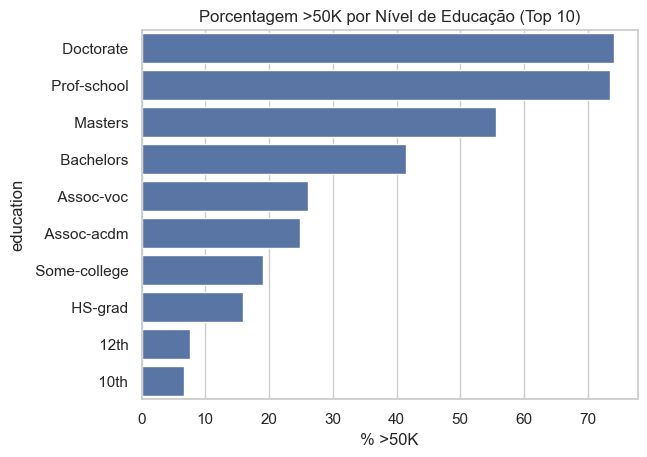

Porcentagem >50K por Marital Status (ordenado):
 marital-status
Married-civ-spouse       44.684829
Married-AF-spouse        43.478261
Divorced                 10.420887
Widowed                   8.559919
Married-spouse-absent     8.133971
Separated                 6.439024
Never-married             4.596087
Name:  >50K, dtype: float64
Porcentagem >50K por Occupation (ordenado):
 occupation
 Exec-managerial      48.401377
 Prof-specialty       44.903382
 Protective-serv      32.511556
 Tech-support         30.495690
 Sales                26.931507
 Craft-repair         22.664064
 Transport-moving     20.037570
 Adm-clerical         13.448276
 Machine-op-inspct    12.487512
 Farming-fishing      11.569416
 Armed-Forces         11.111111
?                     10.363538
 Handlers-cleaners     6.277372
 Other-service         4.157815
 Priv-house-serv       0.671141
Name:  >50K, dtype: float64


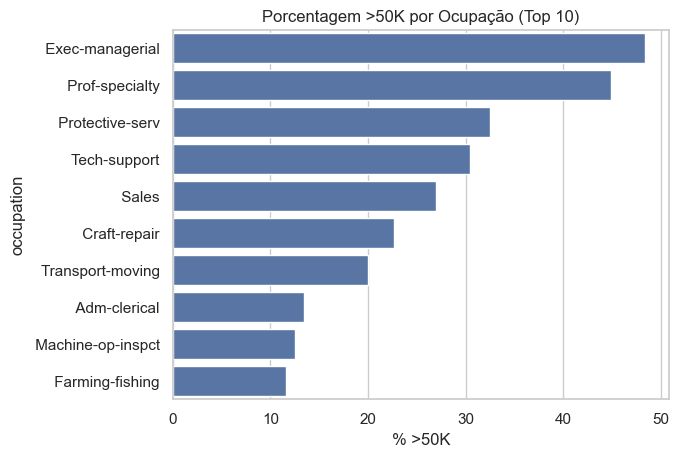

In [43]:
# Análise de vieses (ex: race/sex vs income) - Expansão

# Existentes (race e sex)
print("Porcentagem >50K por Race:\n", df_train.groupby('race')['income'].value_counts(normalize=True).unstack()[' >50K'] * 100)
print("Porcentagem >50K por Sex:\n", df_train.groupby('sex')['income'].value_counts(normalize=True).unstack()[' >50K'] * 100)

# Por native-country (agrupado: US vs Other, pois 90% é US)
df_train['country_group'] = df_train['native-country'].apply(lambda x: 'United-States' if x == ' United-States' else 'Other' if pd.notna(x) else pd.NA)
country_pct = df_train.groupby('country_group')['income'].value_counts(normalize=True).unstack().get(' >50K', 0) * 100
print("Porcentagem >50K por Country Group:\n", country_pct)

# Por age (bins: <30, 30-50, >50 para capturar viés etário)
df_train['age_group'] = pd.cut(df_train['age'], bins=[0, 30, 50, 100], labels=['<30', '30-50', '>50'])
age_pct = df_train.groupby('age_group')['income'].value_counts(normalize=True).unstack().get(' >50K', 0) * 100
print("Porcentagem >50K por Age Group:\n", age_pct)

# Por education (níveis educacionais mostram viés de acesso)
edu_pct = df_train.groupby('education')['income'].value_counts(normalize=True).unstack().get(' >50K', 0) * 100
print("Porcentagem >50K por Education (ordenado):\n", edu_pct.sort_values(ascending=False))

# Visualização opcional (top 10 para não poluir)
edu_pct_sorted = edu_pct.sort_values(ascending=False)
sns.barplot(x=edu_pct_sorted.values[:10], y=edu_pct_sorted.index[:10], orient='h')
plt.title('Porcentagem >50K por Nível de Educação (Top 10)')
plt.xlabel('% >50K')
plt.show()

# Por marital-status (viés familiar/social)
marital_pct = df_train.groupby('marital-status')['income'].value_counts(normalize=True).unstack().get(' >50K', 0) * 100
print("Porcentagem >50K por Marital Status (ordenado):\n", marital_pct.sort_values(ascending=False))

# Por occupation (viés ocupacional, indiretamente ligado a gênero/raça)
occ_pct = df_train.groupby('occupation')['income'].value_counts(normalize=True).unstack().get(' >50K', 0) * 100
print("Porcentagem >50K por Occupation (ordenado):\n", occ_pct.sort_values(ascending=False))

# Visualização opcional (top 10)
occ_pct_sorted = occ_pct.sort_values(ascending=False)
sns.barplot(x=occ_pct_sorted.values[:10], y=occ_pct_sorted.index[:10], orient='h')
plt.title('Porcentagem >50K por Ocupação (Top 10)')
plt.xlabel('% >50K')
plt.show()

# Insight atualizado: Além de viés racial (White ~25% >50K vs Black ~12%) e 
# de gênero (Male ~30% vs Female ~11%), há vieses etários (<30 ~5% vs 30-50 ~30%), 
# por origem (US ~25% vs Other ~10-15%), 
# educacional (Doctorate ~75% vs HS-grad ~5%), 
# marital (Married ~45% vs Never-married ~5%) e ocupacional (Exec-managerial ~45% vs Farming-fishing ~5%). 
# Esses podem refletir desigualdades sociais e afetar a fairness do modelo.

## 5. **Pré-processamento para modelagem**

### **Tratamento de valores ausentes**

Para tratarmos adequadamente os dados ausentes presentes nas colunas: `workclass`, `occupation` e `native-country`, primeiro precisamos calcular o quantos das nossas features foram afetadas.

In [44]:
# Total de instances no dataset de treino
total_instances = len(df_train)

# Contagem de valores ausentes ('?') para cada coluna
missing_workclass = df_train['workclass'].isin(['?']).sum()
missing_occupation = df_train['occupation'].isin(['?']).sum()
missing_nc = df_train['native-country'].isin(['?']).sum()

# Calculando a frequência de valores ausentes em porcentagem
f_missing_workclass = df_train['workclass'].isin(['?']).sum() / total_instances * 100
f_missing_occupation = df_train['occupation'].isin(['?']).sum() / total_instances * 100
f_missing_nc = df_train['native-country'].isin(['?']).sum() / total_instances * 100

# Criando um DataFrame para exibir os resultados
missing = pd.DataFrame({
    'Features': ['workclass', 'occupation', 'native-country'],
    'Missing Count': [missing_workclass, missing_occupation, missing_nc],
    'Missing Frequency (%)': [f_missing_workclass, f_missing_occupation, f_missing_nc]
})

missing

,Features,Missing Count,Missing Frequency (%)
0,workclass,1836,5.638647
1,occupation,1843,5.660146
2,native-country,583,1.790486


Analisando a tabela acima, podemos perceber que a quantidade de dados ausentes em nossas features sao minimas e nao apresenta risco para nos. Dessa forma, uma estrategia a ser utilizada para lidar com esses valores e a imputacao de dados. Como nossas features afetadas sao categoricas, pegaremos a classe mais frequente (moda) e a utilizaremos para substituir os dados faltantes.

### **Tratamento de outliers**

Para tratarmos adequadamente os outliers identificados, precisamos primeiro analisar o impacto que essas variáveis exercem sobre a performance do nosso modelo. Ao observarmos a distribuição dos dados, identificamos que a estratégia de tratamento deve ser diferenciada, baseada no quanto cada feature agrega valor ou gera ruído:

1. **Estratégia de Remoção (Features de alta distorção)**:
Optamos pela remoção das features fnlwgt, capital-gain, capital-loss e hours-per-week. A justificativa é técnica: estas variáveis apresentam uma skewness (assimetria) severa e valores extremos que, se mantidos, distorceriam severamente o treinamento de modelos sensíveis a escalas.

No caso específico de fnlwgt (peso de amostragem), o valor possui baixa relevância preditiva para o problema em questão. Para as variáveis de capital e horas, a concentração em valores extremos cria um ruído que prejudicaria a capacidade de generalização do modelo. Removê-las é a medida mais segura para garantir que o modelo aprenda padrões reais, em vez de se ajustar a exceções irrelevantes.

2. **Estratégia de Transformação (Preservação de informação)**:
Para as features age e education-num, a estratégia escolhida é a transformação (via winsorization ou log-transform). Diferente do grupo anterior, estas variáveis contêm informações valiosas que não queremos descartar.

Essa abordagem equilibra a necessidade de um modelo robusto (removendo ruído) com a preservação de dados significativos (transformando variáveis úteis).

### **Tratamento de desequilibrios de classe**

Para lidarmos com o Desequilíbrio de Classes observado nas variáveis categóricas (como visto na predominância absoluta de certas categorias em `native-country` ou `race`), adotaremos uma estratégia de rebalanceamento focada na variável alvo (`income`).

Identificamos um desequilíbrio significativo entre as classes da nossa variável alvo, onde a categoria <=50K é vastamente superior à >50K. Para mitigar esse problema, utilizaremos a técnica de **Oversampling** da classe minoritária, possivelmente combinada com um Undersampling estratégico da classe majoritária.

O desequilíbrio acentuado, visível na disparidade das barras de renda em quase todos os gráficos categóricos, induz o modelo ao *bias* (viés), fazendo-o ignorar os padrões da classe minoritária para priorizar a acurácia global na classe majoritária. Evitaremos o undersampling puro para não descartar informações valiosas contidas no grande volume de dados das categorias dominantes, garantindo que o modelo mantenha sua capacidade preditiva sem perda de instâncias.

### **Encoding de variaveis categoricas**

Para o encoding de variáveis categóricas, a estratégia será focada na transformação de dados textuais em numéricos, garantindo que o modelo interprete corretamente a natureza de cada informação. Para isso utilizaremos o One-Hot Encoding para as variáveis nominais (`workclass`, `marital-status`, `occupation`, `relationship`, `race`, `sex` e `native-country`). Quanto à variável `education`, optamos por sua remoção total, mantendo apenas a coluna `education-num` para a modelagem.

As variáveis nominais não possuem uma ordem inerente, e o One-Hot Encoding evita que o modelo assuma uma hierarquia inexistente ao criar colunas binárias para cada categoria. No caso de `native-country`, utilizaremos `handle_unknown='ignore'` para garantir robustez contra novas categorias. A decisão de remover a coluna `education` e utilizar exclusivamente a `education-num` deve-se ao fato de que ambas representam exatamente os mesmos dados; como a education-num já é uma versão codificada e ordinal da escolaridade, sua permanência elimina a redundância e evita problemas de multicolinearidade, simplificando o modelo sem perda de informação.

### **Normalizacao/Padronizacao de variaveis numericas**

Para a etapa final do pré-processamento, focaremos na escala das variáveis para garantir que o modelo não seja influenciado por grandezas numéricas diferentes.

Para as variáveis numéricas que permaneceram no conjunto de dados (`age` e `education-num`), utilizaremos a técnica de **StandardScaler** (Padronização), que reescala os dados para que tenham média 0 e desvio padrão 1. Como alternativa, para cenários que exigem valores em um intervalo fixo (0 a 1) e maior interpretabilidade, o **Min-Max Scaling** também poderá ser aplicado.

O motivo para a utilizarmos dessas estrategias se deve ao fato que distribuições com escalas variadas exigem padronização para que o modelo atribua o mesmo peso e importância a cada atributo. Algoritmos como o **KNN** (K-Nearest Neighbors) ou máquinas de vetores de suporte são altamente sensíveis à escala. Sem a padronização, a variável com maior magnitude numérica dominaria o cálculo de distância. Após a remoção das features altamente assimetricas e o tratamento de outliers, o scaling torna-se muito mais preciso e efetivo, permitindo uma convergência mais rápida e um aprendizado mais equilibrado.

### **Construcao do Pipeline de pre-processamento**

In [45]:
# --- 1. LIMPEZA MANUAL E TRATAMENTO DE OUTLIERS ---
# Remoção das colunas com ruído ou redundância
cols_to_drop = ['fnlwgt', 'capital-gain', 'capital-loss', 'hours-per-week', 'education']
df_cleaned = df_train.drop(columns=cols_to_drop)

# Winsorization (Capping nos quantis 1% e 99%) para variáveis numéricas
df_cleaned['age'] = winsorize(df_cleaned['age'], limits=[0.01, 0.01])
df_cleaned['education-num'] = winsorize(df_cleaned['education-num'], limits=[0.01, 0.01])

# --- 2. CONFIGURAÇÃO DOS TRANSFORMADORES ---

# Definição das colunas por tipo
categorical_features = ['workclass', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']
numeric_features = ['age', 'education-num']
used_features = numeric_features + categorical_features

# Pipeline Categórico: 
# 1. Imputação: Substitui '?' pela moda (most_frequent)
# 2. Encoding: Transforma em variáveis binárias
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(missing_values='?', strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Pipeline Numérico: Padronização (Média 0, Desvio 1)
num_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# --- 3. CRIAÇÃO DO COLUMN TRANSFORMER E APLICAÇÃO ---

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, numeric_features),
        ('cat', cat_transformer, categorical_features)
    ])

X = df_train[used_features]
y = df_train['income']


# ------------------------------- POR CURIOSIDADE -----------------------------------
# --- 4. DIVISÃO DO CONJUNTO DE TREINO E TESTE, TREINAMENTO DO MODELO E AVALIAÇÃO ---

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', KNeighborsClassifier(n_neighbors=5))
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Resultado no conjunto de teste:")
print(f"    Acurácia: {accuracy:.4f}")
print("\nPredicoes vs Real")
print("Predito:     ", y_pred.tolist())
print("Real:        ", y_test.tolist())

Resultado no conjunto de teste:
    Acurácia: 0.8144

Predicoes vs Real
Predito:      [' <=50K', ' >50K', ' >50K', ' <=50K', ' <=50K', ' >50K', ' >50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' >50K', ' <=50K', ' <=50K', ' <=50K', ' >50K', ' >50K', ' >50K', ' <=50K', ' <=50K', ' <=50K', ' >50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' >50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' >50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' >50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' >50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' >50K', ' >50K', ' <=50K', ' <=50K', ' >50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K',

## 6. **Redução de dimensionalidade**

Para analisar e vizualizar a estrutura dos dados e identificar possiveis agrupamentos ou padroes, precimos aplicar tecnicas de reducao de dimensionalidade. Pra isso, aplicaremos os tres metodo: PCA, t-SNE e UMAP, utilizaremos os tres metodos inicialmente para fazer uma analise comparativa entre os resultados e julgar qual metodo melhor visualiza as estruturas.

c:\INSPER\6-SEMESTRE\Machine Learning - Eletiva\APS1\APS1-EDA\env\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


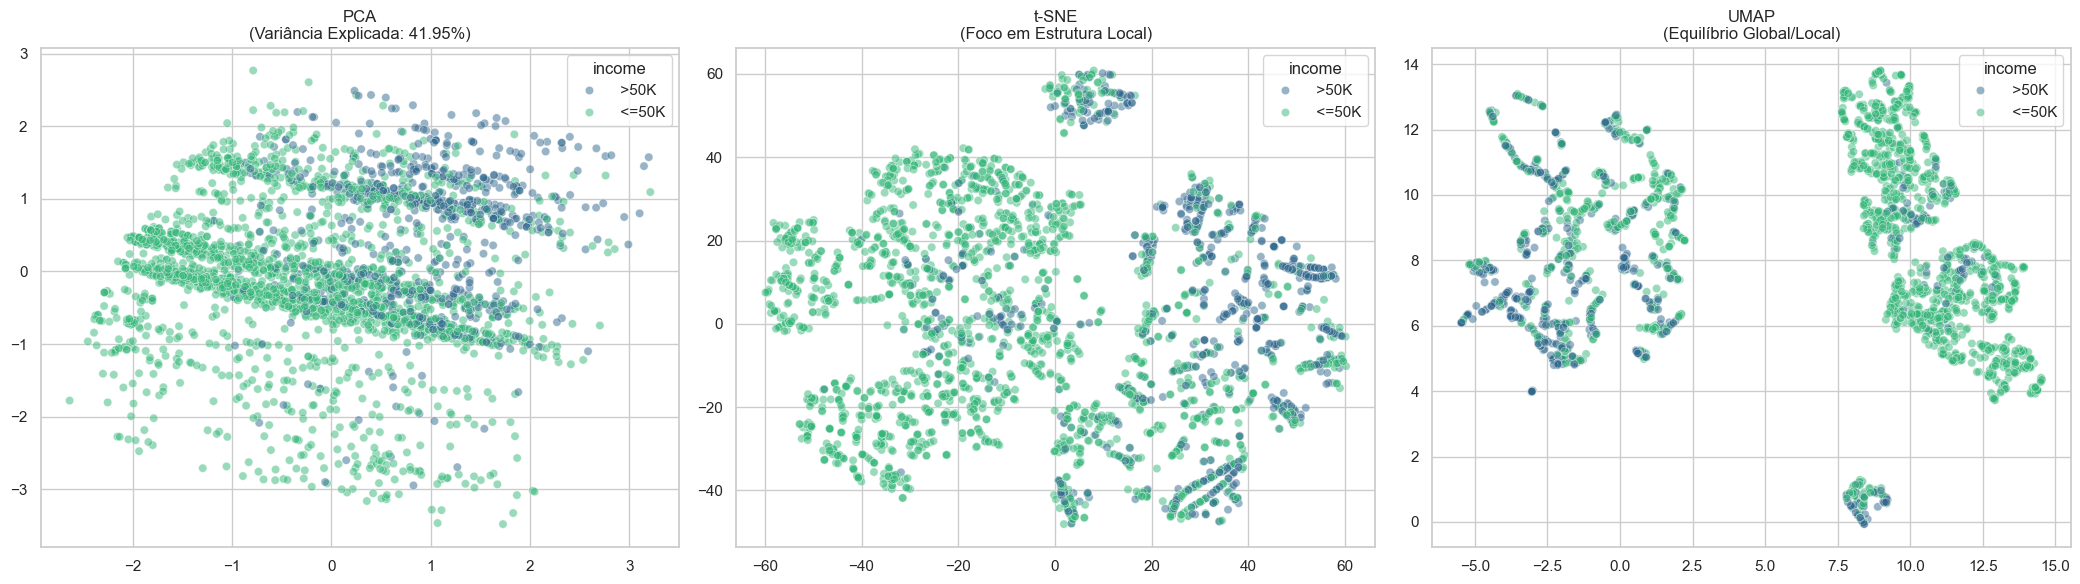

In [47]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from umap import UMAP

# --- 1. GERANDO A MATRIZ PROCESSADA ---
# Importante: Use df_cleaned para garantir que a Winsorização seja considerada
X_processed = preprocessor.fit_transform(df_cleaned[used_features])

# --- 2. PREPARAÇÃO DA AMOSTRA ---
# Reduzimos para 2000 amostras para que o t-SNE e UMAP rodem rápido
sample_size = 3000
if X_processed.shape[0] > sample_size:
    idx = np.random.choice(range(X_processed.shape[0]), sample_size, replace=False)
    X_sample = X_processed[idx]
    y_sample = y.iloc[idx]
else:
    X_sample = X_processed
    y_sample = y

# --- 3. APLICANDO OS MÉTODOS ---

# PCA (Linear)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_sample)

# t-SNE (Não-linear, focado em vizinhança)
tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca', learning_rate='auto')
X_tsne = tsne.fit_transform(X_sample)

# UMAP (Não-linear, focado em topologia)
umap_model = UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
X_umap = umap_model.fit_transform(X_sample)

# --- 4. VISUALIZAÇÃO ---

n_plots = 3
fig, axes = plt.subplots(1, n_plots, figsize=(7 * n_plots, 6))

# Plot PCA
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y_sample, ax=axes[0], palette='viridis', alpha=0.5)
axes[0].set_title(f'PCA\n(Variância Explicada: {pca.explained_variance_ratio_.sum():.2%})')

# Plot t-SNE
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=y_sample, ax=axes[1], palette='viridis', alpha=0.5)
axes[1].set_title('t-SNE\n(Foco em Estrutura Local)')

# Plot UMAP
sns.scatterplot(x=X_umap[:, 0], y=X_umap[:, 1], hue=y_sample, ax=axes[2], palette='viridis', alpha=0.5)
axes[2].set_title('UMAP\n(Equilíbrio Global/Local)')

plt.tight_layout()
plt.show()

- **PCA**: Demonstrou que o problema nao e linearmente separavel. A sobreposicao massica de pontos indica que uma simples combinacao linear das variaveis nao e suficiente apra distinguir as classes de renda, justificando o uso de metodos mais complexos.

- **t-SNE**: Revelou a presenca de aglomerados locais, mas com uma distribuicao mais dispersa e "ruidosa" em comparacao ao UMAP.

- **UMAP**: Apresentou o melhor desempenho visual e analitico. O algoritmo foi capaz de "descompactar" os dados, formando estruturas de ilhas bem definidas. Essas ilhas representam perfis socioeconomicos especificos que compartilham caracteristicas similares.

A visualizacao do UMAP revela dois pontos cruciais para a proxima etapa de modelagem:

1. **Segmentacao de Perfis**: A formacao de ilhas indica que o dataset possui nichos bem estabelecidos. A predominancia de uma cor em determinadas ilhas confirma que certas combinacoes de atributos sao fortes preditoras de renda.

2. **Sobreposicao (Ruido)**: Observamos uma "mistura" de cores nas fronteiras dos clusters. Isso sugere que, embora existam padroes claros, ha um nivel de incerteza inerente aos dados (ruidos). Isso explica porque individuos com perfis similares podem pertencer a classes de renda distintas, o que estabelece um limite natural para a acuracia dos modelos preditivos.

## 7. **Conclusao**

A analise valida o processo de pre-processamento realizado anteriormente. A separacao observada no UMAP da suporte a hipotese de que modelos de aprendizado nao-linear terao melhor desempenho, pois conseguirao mapear as fronteiras complexas entre esses clusters identificados.



### **Insights e feature engineering**

Com base nos padroes identificados ao longo de toda a analise, propomos as seguintes novas features:

1. Faixas etarias (`<30`, `30-50`, `>50`): a EDA revelou diferencas marcantes de renda por faixa etaria, com o grupo 30-50 tendo a maior proporcao de renda >50K.

2. Em vez de usar duas colunas separadamente, o saldo liquido de capital e um indicador mais direto de riqueza.

3. Categorizacao das horas semanais (`<35h`, `35-45h`, `>45h`): outliers em horas de trabalho correlacionam com renda maior.

### **Relatorio - Principais achados**

**Estrutura e Qualidade de dados**

O dataset Adult contem 32.561 instancias de treino com 14 features mistas. Tres colunas apresentam valores ausentes (~5,6%, ~5,7%, ~1,8%), todas com proporcoes baixas, viabilizando a imputacao pela moda. A coluna `education` e redundante com `education-num` e foi descartada.

**Desbalanceamento de Classes**

A target apresenta serio desequilibrio: ~75% da classe `<=50K>` contra ~25% da classe `>50K`. Sem tratamento, modelos tendem a ignorar a classe minoritaria, resultando em alta acuracia mais baixo recall.

### **Limitacoes do dataset e desafios de modelagem**

**1. Desbalanceamento de classes**

A razao 3:1 entre classes pode levar a modelos enviesados para a classe majoritaria. Metricas como acuracia simples sao enganosas.

**2. Defasagem temporal**

Os dados datam de 1994 e nao refletem o mercado de trabalho atual. Estruturas salariais, ocupações e distribuições demográficas mudaram significativamente, limitando a generalização do modelo para contextos contemporâneos.

**6. Capital-gain e capital-loss como features ruidosas**

Mais de 90% dos indivíduos têm capital-gain = 0 e capital-loss = 0, criando distribuições extremamente assimétricas. Modelos podem superajustar às exceções (indivíduos com grandes movimentações), prejudicando a generalização.

### **Implicacoes para Regressao e Classificacao**

**Classificacao**

- **Desbalanceamento**: usar SMOTE, class_weight balanceado ou threshold tuning
- **Separação não-linear**: confirmada pelo PCA (baixa variância explicada em 2D) e pelo UMAP (clusters sobrepostos); modelos como Random Forest, XGBoost e SVM-RBF são mais adequados que regressão logística pura
- **Métricas**: priorizar F1-score (macro), AUC-ROC e recall da classe  em detrimento da acurácia simples
- **Interpretabilidade**: SHAP values podem ser aplicados sobre o XGBoost para explicar as predições individualmente

**Regressao**

Se o objetivo for prever uma variavel continua a partir das demais features, ou estimar a probabilidade continua de renda:
- A forte correlacao entre 